# qp_litebird vs. SMARTIES validation



In [20]:
import os
import numpy as np
import healpy as hp
import matplotlib.pylab as plt

import litebird_sim as lbs
import smarties as sm
from smarties.io import build_mask_from_lbs_h_maps, read_lbs_h_maps
from smarties.sky.convolution import get_beam_convolution_spins_maps
from smarties.utils.tools import transform_array_maps_into_spin_maps
os.chdir('/home/camille/Documents/PhD/qp_litebird')
import qp_litebird as qp
%matplotlib inline


In [21]:
# ---- Settings ------------------------------------------------------------
telescope = "LFT"
channel = "L1-040"
detlist = [
    "000_000_003_QA_040_T",
    "000_000_003_QA_040_B",
    "000_000_004_QB_040_T",
    "000_000_004_QB_040_B",
]

start_time = 0
mission_time_days = 185
imo_version = "vPTEP"

# Resolution and harmonic-space settings
nside = 256
lmax = 2 * nside
smax = 6
mmax_quickpol = smax + 2   # = 8
mmax_smarties = smax - 2   # = 4  (smarties: smax = mmax + 2)

# Beams (ellipticity kept modest so the beam is m-converged at mmax=4)
fwhm_arcmin = 30.0
ellipticity = 1.0
ellipse_angle = np.random.uniform(0, 2 * np.pi, len(detlist))
pol_angles = [0.1, np.pi / 2, -0.08 + np.pi / 4, 3 * np.pi / 4]

# Cross-polar efficiency: keep Ideal (rho=1) to match the SMARTIES side,
# which does not apply pol_efficiency in this demo.
rho_beam = "Ideal"
rho_hit = "Ideal"


In [22]:
# ---- Build the LiteBIRD instrument / detectors -------------------------
base_path = ".test"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)

sim = lbs.Simulation(
    base_path=base_path,
    imo=imo,
    start_time=start_time,
    duration_s=mission_time_days * 24 * 3600.0,
    random_seed=12345,
)

sim.set_instrument(
    lbs.InstrumentInfo.from_imo(
        imo, f"/releases/{imo_version}/satellite/{telescope}/instrument_info"
    )
)

dets = []
for name_det in detlist:
    det = lbs.DetectorInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{name_det}/detector_info",
        imo=imo,
    )
    det.sampling_rate_hz = 1
    det.ellipticity = ellipticity
    det.fwhm_arcmin = fwhm_arcmin
    det.pol_angle_rad = pol_angles[detlist.index(name_det)]
    det.psi_rad = ellipse_angle[detlist.index(name_det)]
    dets.append(det)

sim.set_scanning_strategy(imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/")


In [23]:
# ---- Observations and pointings -----------------------------------------
(obs,) = sim.create_observations(
    detectors=dets,
    n_blocks_det=1,
    n_blocks_time=1,
    tods=[lbs.TodDescription(
        name="convolve_sky", units=lbs.Units.uK_CMB, description="CMB", dtype=np.float64
    )],
)
sim.prepare_pointings()


In [24]:
# ---- Input CMB sky ------------------------------------------------------
sky_params = lbs.SkyGenerationParams(
    make_cmb=True, make_fg=False, seed_cmb=1, apply_beam=False,
    bandpass_integration=False, units="uK_CMB", output_type="alm", lmax=lmax,
)
alm_sky = sim.get_sky(parameters=sky_params)


[2026-10-07 16:57:33,642 INFO MPI#0000] Generating CMB...


[2026-10-07 16:57:33,707 INFO MPI#0000] Summing components...


In [25]:
# ---- Beams (one SphericalHarmonics per detector) -----------------------
# qp_litebird consumes SphericalHarmonics directly (mmax = smax + 2).
blms = sim.get_gauss_beam_alms(lmax=lmax, mmax=mmax_quickpol)
beams_qp = {det.name: blms[det.name] for det in dets}

# SMARTIES consumes plain .values arrays resized to (lmax, lmax).
beams_smarties = {
    det.name: blms[det.name].resize_alm(lmax, lmax).values for det in dets
}


In [26]:
# ---- LiteBIRD h-maps (all integer spins n = 0..smax) -------------------
spins = np.array([[n, 0] for n in range(smax + 1)])  # [[0,0],[1,0],...,[6,0]]
# result_hmap = lbs.make_h_maps(
#     sim.observations, nside, n_m_couples=spins,
#     save_to_file=True, output_directory=base_path,
# )


## 1) `qp_litebird` — beam-mixing matrix


In [27]:
# Run the QuickPol core on the LiteBIRD h-maps and beams.
detset = qp.DetectorSet(dets, beams_qp, base_path, rho_beam=rho_beam, rho_hit=rho_hit)
result = qp.hmap2mat(
    detset,
    smax=smax, nside=nside, lmax=lmax, mmax=mmax_quickpol,
)
beam_mat = result.beam_mat
print("beam matrix shapes:", {k: v.shape for k, v in beam_mat.items()})
print("TT[0,0,0] =", beam_mat["TT"][0, 0, 0])


[2026-10-07 16:57:33,750 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_T.h5


[2026-10-07 16:57:33,807 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_B.h5
[2026-10-07 16:57:33,856 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_004_QB_040_T.h5
[2026-10-07 16:57:33,905 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_004_QB_040_B.h5
[2026-10-07 16:57:34,069 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_T.h5
[2026-10-07 16:57:34,116 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_B.h5
[2026-10-07 16:57:34,164 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_004_QB_040_T.h5
[2026-10-07 16:57:34,212 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_004_QB_040_B.h5
[2026-10-07 16:57:34,372 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_T.h5
[2026-10-07 16:57:34,420 INFO MPI#0000] Loading h maps from file:.test/h_maps_det_000_000_003_QA_040_B.h5
[2026-10-07 16:57:34,468 INFO MPI#0000] Loadin

beam matrix shapes: {'TT': (513, 3, 3), 'TE': (513, 3, 3), 'EE': (513, 3, 3), 'BB': (513, 3, 3), 'TB': (513, 3, 3), 'EB': (513, 3, 3)}
TT[0,0,0] = 0.9691619873046875


In [28]:
# Predicted mixed power spectra: realized input Cl x beam matrix.
cl_true = hp.alm2cl(alm_sky[dets[0].name].values)  # (4, lmax+1): TT, EE, BB, TE
qp_spectra = qp.get_spectra(beam_mat, cl_true, lmax)  # (6, lmax+1)
print("qp_spectra shape:", qp_spectra.shape)


qp_spectra shape: (6, 513)


## 2) SMARTIES — map-level convolution (ground truth)


In [29]:
h_maps_names = [os.path.join(base_path, f"h_maps_det_{det.name}") for det in dets]
mask_hits, detectors_hits = build_mask_from_lbs_h_maps(
    h_maps_names, format_file="h5", spin_to_read=(0, 0), return_detectors_hits=True,
)
h_n_spin_dict = read_lbs_h_maps(
    h_maps_names,
    list_spin=np.array([[0, 0], [2, 0], [4, 0], [6, 0]]),
    prefix="h_maps_det_", list_weights=None, mask=mask_hits,
    format_file="h5", single_precision=False,
)


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:01<00:00,  2.16it/s]

Finalizing h_n dictionary...
--Spin 0 in h maps dictionary, re-weighting applied.
(4, 786111)


No HWP angle spins, removing m=0 spins from the h_nm dictionary...


In [30]:
syst = sm.FrameworkSystematics(
    map_shape=(1, mask_hits.size), nstokes=3, lmax=lmax, list_spin_output=[0, -2, 2],
)
alm_sky_smarties = {det.name: alm_sky[det.name].values for det in dets}

spin_systematics_maps = get_beam_convolution_spins_maps(
    alm_sky_smarties, beams_smarties, [det.name for det in dets],
    lmax, mmax_smarties,
    shape_pixels_output=(hp.nside2npix(nside),),
    pol_angles_rad=np.array([det.pol_angle_rad for det in dets]),
    substract_gaussian_beam=False,
)
spin_systematics_maps_masked = sm.Spin_maps.from_dictionary({
    s: spin_systematics_maps[s][:, mask_hits != 0] for s in spin_systematics_maps
})


In [31]:
empty_sky = transform_array_maps_into_spin_maps(
    np.zeros((3, np.sum(mask_hits))), n_stokes_output=3
)
final_maps, inverse_mapmaking_matrix = syst.compute_total_maps(
    mask_hits, h_n_spin_dict, empty_sky, spin_systematics_maps_masked,
    return_Q_U=True, return_inverse_mapmaking_matrix=True, mask_input=False,
    polar_angle=np.array([det.pol_angle_rad for det in dets]),
)

convolved = np.ones((3, mask_hits.shape[0]), dtype=complex) * hp.UNSEEN
convolved[0, mask_hits != 0] = final_maps[0].real
convolved[1, mask_hits != 0] = final_maps[1].real
convolved[2, mask_hits != 0] = final_maps[2].real


Inverse mapmaking matrix computed in 2.20 seconds
Finishing the mapmaking process, computing the total maps...
Computing the spin coupled maps...
Coupled spins for spin 0: [(4, -4), (2, -2), (0, 0), (-2, 2), (-4, 4)]
Coupled spins for spin 2: [(6, -4), (4, -2), (2, 0), (0, 2), (-2, 4)]
Coupled spins for spin -2: [(2, -4), (0, -2), (-2, 0), (-4, 2), (-6, 4)]
Computing the final CMB fields...
Final CMB fields computed, transforming them into Spin_maps...


## 3) Comparison


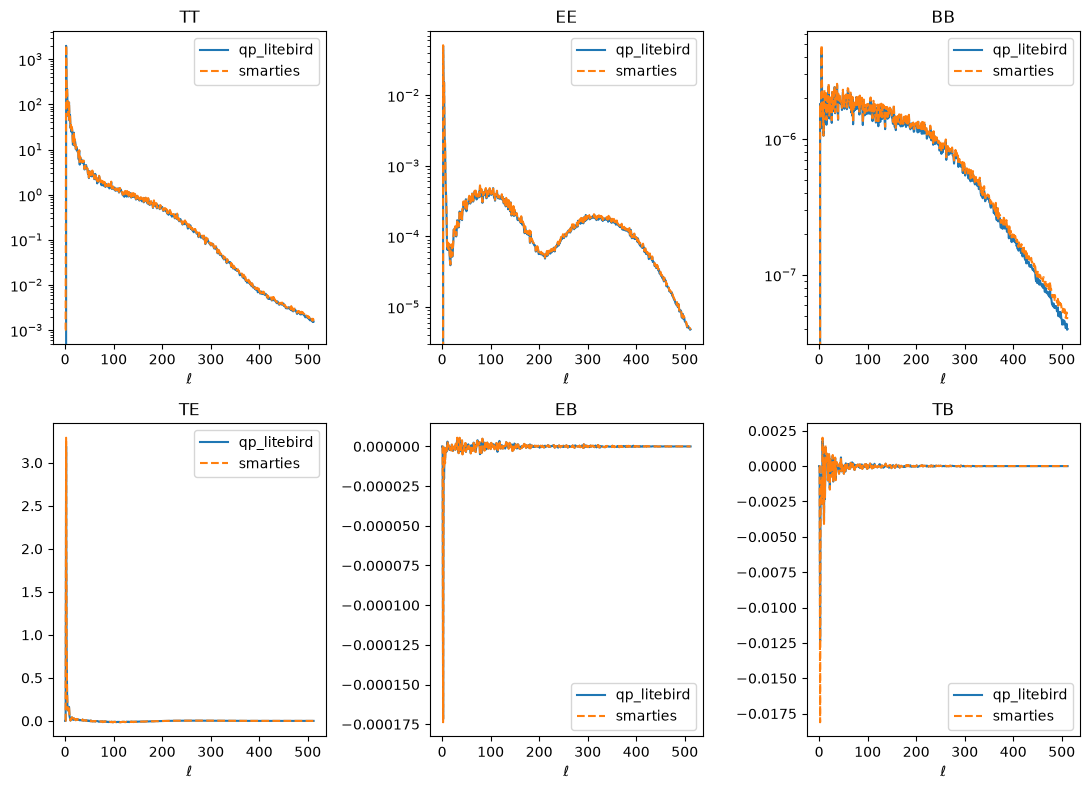

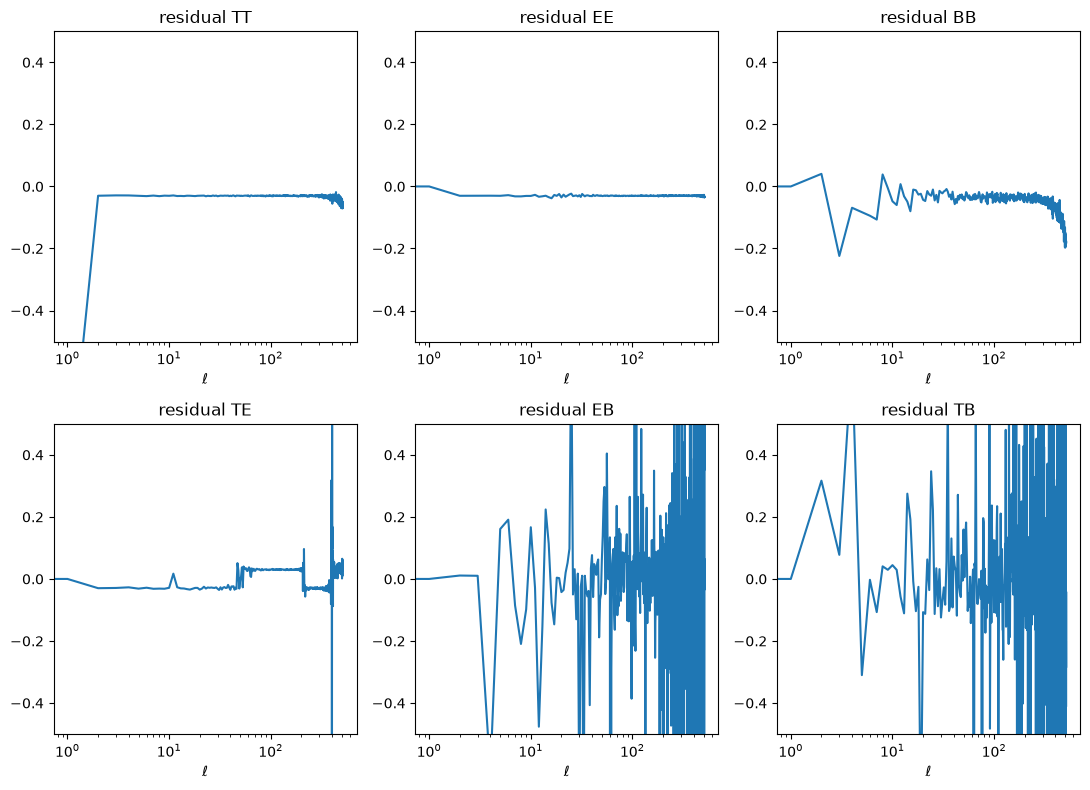

In [33]:
# Observed power spectra from the SMARTIES convolved map.
smarties_cl = hp.anafast(convolved, lmax=lmax, pol=True)  # (4, lmax+1)

labels = ["TT", "EE", "BB", "TE","EB","TB"]
fig, axes = plt.subplots(2, 3, figsize=(11, 8))
for idx, (ax, label) in enumerate(zip(axes.ravel(), labels)):
    if idx<3:
        ax.semilogy(qp_spectra[idx], label="qp_litebird")
        ax.semilogy(smarties_cl[idx], label="smarties", ls="--")
    else:
        ax.plot(qp_spectra[idx], label="qp_litebird")
        ax.plot(smarties_cl[idx], label="smarties", ls="--")
    ax.set_title(label)
    
    ax.legend()
    ax.set_xlabel(r"$\ell$")
plt.tight_layout()
plt.show()

# Relative residual (single CMB realization -> sample variance dominates).
fig, axes = plt.subplots(2, 3, figsize=(11, 8))
for idx, (ax, label) in enumerate(zip(axes.ravel(), labels)):
    residual = (qp_spectra[idx] - smarties_cl[idx]) / np.maximum(np.abs(smarties_cl[idx]), 1e-30)
    ax.semilogx(residual)
    ax.set_title(f"residual {label}")
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel(r"$\ell$")
plt.tight_layout()
plt.show()
